# Notebook 06: Final Model Comparison and Analysis

Here, we bring together the results from our four distinct Mixture Models:
1. **Gaussian Mixture Model (GMM):** Trained on PCA-compressed data.
2. **Laplacian Mixture Model (LMM):** Trained on PCA-compressed data.
3. **Bernoulli Mixture Model (BMM):** Trained on uncompressed, binarized pixel data.
4. **Student-t Mixture Model (SMM):** Trained on PCA-compressed data with heavy tails.

We will compare their clustering performance using **Accuracy (Purity)**, **Adjusted Rand Index (ARI)**, and **Normalized Mutual Information (NMI)**.

In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

REQUIRED_METRIC_KEYS = ['Accuracy', 'ARI', 'NMI']

def load_metrics(filepath, name):
    try:
        with open(filepath, 'rb') as f:
            raw = pickle.load(f)
    except FileNotFoundError:
        print(f"Warning: {filepath} not found.")
        raw = {}

    # Keep comparison robust even if a metrics file misses a key.
    clean = {k: float(raw.get(k, 0.0)) for k in REQUIRED_METRIC_KEYS}
    return clean

# Load metrics
gmm_metrics = load_metrics('data/gmm_metrics.pkl', 'GMM')
lmm_metrics = load_metrics('data/laplacian_metrics.pkl', 'LMM')
bmm_metrics = load_metrics('data/bmm_metrics.pkl', 'BMM')
smm_metrics = load_metrics('data/smm_metrics.pkl', 'SMM')

# Create a Pandas DataFrame for easy viewing
df_metrics = pd.DataFrame(
    [gmm_metrics, lmm_metrics, bmm_metrics, smm_metrics],
    index=['Gaussian (PCA)', 'Laplacian (PCA)', 'Bernoulli (Binary)', 'Student-t (PCA)']
 )

print("--- Final Clustering Metrics (K=25) ---")
display(df_metrics.round(4))

--- Final Clustering Metrics (K=25) ---


,Accuracy,ARI,NMI
Gaussian (PCA),0.7689,0.3592,0.6206
Laplacian (PCA),0.7071,0.2886,0.5385
Bernoulli (Binary),0.7595,0.3285,0.5754
Student-t (PCA),0.7318,0.3133,0.5667


## Are Gaussians the best choice?

Based on the main results table above, GMM is the strongest model in this setup. It gets Accuracy = 0.7689, ARI = 0.3592, and NMI = 0.6206, which are all the best among the four models. Bernoulli is close on Accuracy (0.7595), but still lower overall.

This is reasonable for our pipeline. We are clustering in PCA-50 space, and those features are smoother and more compact than raw pixels. In that space, Gaussian components already fit the data well, so the extra robustness from Student-t and the sharper Laplacian shape does not translate into better clustering scores.

The confusion patterns also match what we expect on MNIST: visually similar digits are still the hardest to separate. Pairs like 4/9 and 3/5 remain frequent errors across models, so changing the distribution helps only a little with those overlaps.

**Final verdict:** For MNIST with PCA-50 preprocessing, **GMM is the best overall choice** in this project, with Bernoulli as a competitive second option.

In [10]:
# Held-out log-likelihood + confusion summary (small split, comparable protocol)
import pickle
from scipy.special import logsumexp, digamma, gammaln
from scipy.optimize import brentq
from scipy.stats import mode
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

class QuickLaplacianMM:
    def __init__(self, n_components=25, max_iter=10, tol=1e-4):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol

    def _log_pdf(self, X, k):
        b = np.clip(self.b[k], 1e-4, None)
        return np.sum(-np.log(2 * b) - np.abs(X - self.mu[k]) / b, axis=1)

    def _e_step(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + self._log_pdf(X, k)
        norm = logsumexp(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - norm)
        return resp, float(np.sum(norm))

    def _m_step(self, X, resp):
        Nk = resp.sum(axis=0) + 1e-12
        self.pi = Nk / X.shape[0]
        self.mu = (resp.T @ X) / Nk[:, None]
        for k in range(self.K):
            self.b[k] = np.sum(resp[:, k][:, None] * np.abs(X - self.mu[k]), axis=0) / Nk[k]
        self.b = np.clip(self.b, 1e-4, None)

    def fit(self, X):
        km = KMeans(n_clusters=self.K, init='k-means++', n_init=10, random_state=42).fit(X)
        self.mu = km.cluster_centers_.copy()
        self.b = np.ones_like(self.mu)
        self.pi = np.ones(self.K) / self.K
        prev = None
        for _ in range(self.max_iter):
            resp, ll = self._e_step(X)
            self._m_step(X, resp)
            if prev is not None and abs(ll - prev) < self.tol:
                break
            prev = ll
        return self

    def predict(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + self._log_pdf(X, k)
        return np.argmax(log_resp, axis=1)

    def score(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + self._log_pdf(X, k)
        return float(np.mean(logsumexp(log_resp, axis=1)))

    def sample_from_component(self, k, n=1):
        return np.random.laplace(loc=self.mu[k], scale=np.clip(self.b[k], 1e-4, None), size=(n, self.mu.shape[1]))

class QuickBernoulliMM:
    def __init__(self, n_components=25, max_iter=12, tol=1e-4):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol

    def _e_step(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            p = np.clip(self.mu[k], 1e-6, 1 - 1e-6)
            log_pdf = np.sum(X * np.log(p) + (1 - X) * np.log(1 - p), axis=1)
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + log_pdf
        norm = logsumexp(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - norm)
        return resp, float(np.sum(norm))

    def _m_step(self, X, resp):
        Nk = resp.sum(axis=0) + 1e-12
        self.pi = Nk / X.shape[0]
        self.mu = (resp.T @ X) / Nk[:, None]
        self.mu = np.clip(self.mu, 1e-6, 1 - 1e-6)

    def fit(self, X):
        km = KMeans(n_clusters=self.K, init='k-means++', n_init=10, random_state=42).fit(X)
        self.mu = np.clip(km.cluster_centers_, 1e-3, 1 - 1e-3)
        self.pi = np.ones(self.K) / self.K
        prev = None
        for _ in range(self.max_iter):
            resp, ll = self._e_step(X)
            self._m_step(X, resp)
            if prev is not None and abs(ll - prev) < self.tol:
                break
            prev = ll
        return self

    def predict(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            p = np.clip(self.mu[k], 1e-6, 1 - 1e-6)
            log_pdf = np.sum(X * np.log(p) + (1 - X) * np.log(1 - p), axis=1)
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + log_pdf
        return np.argmax(log_resp, axis=1)

    def score(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            p = np.clip(self.mu[k], 1e-6, 1 - 1e-6)
            log_pdf = np.sum(X * np.log(p) + (1 - X) * np.log(1 - p), axis=1)
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + log_pdf
        return float(np.mean(logsumexp(log_resp, axis=1)))

    def sample_from_component(self, k, n=1):
        p = np.clip(self.mu[k], 1e-6, 1 - 1e-6)
        return np.random.binomial(1, p, size=(n, p.shape[0]))

class QuickStudentTMM:
    def __init__(self, n_components=25, max_iter=8, tol=1e-4):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol

    def _student_t_log_pdf(self, X, k):
        _, D = X.shape
        sigma2_k = np.clip(self.sigma2[k], 1e-6, None)
        mu_k = self.mu[k]
        nu_k = self.nu[k]
        diff = X - mu_k
        delta = np.sum((diff ** 2) / sigma2_k, axis=1)
        log_det = np.sum(np.log(np.pi * nu_k * sigma2_k))
        log_norm = gammaln((nu_k + D) / 2.0) - gammaln(nu_k / 2.0) - 0.5 * log_det
        log_kernel = -((nu_k + D) / 2.0) * np.log1p(delta / nu_k)
        u = (nu_k + D) / (nu_k + delta + 1e-12)
        return log_norm + log_kernel, u

    def _e_step(self, X):
        N, _ = X.shape
        log_resp = np.zeros((N, self.K))
        u = np.zeros((N, self.K))
        for k in range(self.K):
            log_pdf, uk = self._student_t_log_pdf(X, k)
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + log_pdf
            u[:, k] = uk
        norm = logsumexp(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - norm)
        return resp, u, float(np.sum(norm))

    def _update_nu(self, resp, u, D):
        Nk = resp.sum(axis=0) + 1e-12
        for k in range(self.K):
            c_k = np.sum(resp[:, k] * (np.log(u[:, k] + 1e-12) - u[:, k])) / Nk[k]
            def f(nu):
                return -digamma(nu / 2.0) + np.log(nu / 2.0) + 1.0 + c_k + digamma((nu + D) / 2.0) - np.log((nu + D) / 2.0)
            low, high = 0.1, 100.0
            f_low, f_high = f(low), f(high)
            if np.isfinite(f_low) and np.isfinite(f_high) and f_low * f_high < 0:
                self.nu[k] = brentq(f, low, high)

    def _m_step(self, X, resp, u):
        N, D = X.shape
        Nk = resp.sum(axis=0) + 1e-12
        self.pi = Nk / N
        ru = resp * u
        for k in range(self.K):
            denom = np.sum(ru[:, k]) + 1e-12
            self.mu[k] = np.sum(ru[:, k][:, None] * X, axis=0) / denom
            sq = (X - self.mu[k]) ** 2
            self.sigma2[k] = np.sum(ru[:, k][:, None] * sq, axis=0) / Nk[k]
        self.sigma2 = np.clip(self.sigma2, 1e-6, None)
        self._update_nu(resp, u, D)

    def fit(self, X):
        _, D = X.shape
        km = KMeans(n_clusters=self.K, init='k-means++', n_init=10, random_state=42).fit(X)
        self.mu = km.cluster_centers_.copy()
        self.sigma2 = np.ones((self.K, D))
        self.pi = np.ones(self.K) / self.K
        self.nu = np.ones(self.K) * 10.0
        prev = None
        for _ in range(self.max_iter):
            resp, u, ll = self._e_step(X)
            self._m_step(X, resp, u)
            if prev is not None and abs(ll - prev) < self.tol:
                break
            prev = ll
        return self

    def predict(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            log_pdf, _ = self._student_t_log_pdf(X, k)
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + log_pdf
        return np.argmax(log_resp, axis=1)

    def score(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            log_pdf, _ = self._student_t_log_pdf(X, k)
            log_resp[:, k] = np.log(self.pi[k] + 1e-12) + log_pdf
        return float(np.mean(logsumexp(log_resp, axis=1)))

    def sample_from_component(self, k, n=1):
        z = np.random.standard_t(df=self.nu[k], size=(n, self.mu.shape[1]))
        return self.mu[k] + np.sqrt(np.clip(self.sigma2[k], 1e-6, None)) * z

def map_clusters_to_digits(y_true, y_pred, n_clusters):
    labels = np.zeros_like(y_pred)
    for cluster in range(n_clusters):
        mask = (y_pred == cluster)
        if np.any(mask):
            labels[mask] = mode(y_true[mask], keepdims=False).mode
    return labels

def top_confusions(cm, top_n=3):
    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                pairs.append((cm[i, j], i, j))
    pairs.sort(reverse=True)
    return [f"{i}->{j} ({cnt})" for cnt, i, j in pairs[:top_n]]

# Small subset split for a fast, comparable held-out estimate
rng = np.random.default_rng(42)
X_pca_full = np.load('data/X_pca.npy')
X_bin_full = np.load('data/X_binary.npy')
y_full = np.load('data/y_labels.npy')

subset_idx = rng.choice(len(X_pca_full), size=15000, replace=False)
X_pca_sub = X_pca_full[subset_idx]
X_bin_sub = X_bin_full[subset_idx]
y_sub = y_full[subset_idx]

X_pca_train, X_pca_val, X_bin_train, X_bin_val, y_train, y_val = train_test_split(
    X_pca_sub, X_bin_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

K = 25
gmm_hold = GaussianMixture(n_components=K, covariance_type='diag', n_init=3, random_state=42).fit(X_pca_train)
lmm_hold = QuickLaplacianMM(n_components=K, max_iter=10).fit(X_pca_train)
bmm_hold = QuickBernoulliMM(n_components=K, max_iter=12).fit(X_bin_train)
smm_hold = QuickStudentTMM(n_components=K, max_iter=8).fit(X_pca_train)

heldout_ll_df = pd.DataFrame(
    {
        'Model': ['GMM (diag)', 'LMM', 'BMM', 'SMM'],
        'Held-out Avg Log-Likelihood': [
            gmm_hold.score(X_pca_val),
            lmm_hold.score(X_pca_val),
            bmm_hold.score(X_bin_val),
            smm_hold.score(X_pca_val),
        ],
    }
)
print('--- Held-out Average Log-Likelihood (small validation split) ---')
display(heldout_ll_df.round(4))

# Confusion summary (top-3 off-diagonal pairs) from the same validation split
pred_gmm = map_clusters_to_digits(y_val, gmm_hold.predict(X_pca_val), K)
pred_lmm = map_clusters_to_digits(y_val, lmm_hold.predict(X_pca_val), K)
pred_bmm = map_clusters_to_digits(y_val, bmm_hold.predict(X_bin_val), K)
pred_smm = map_clusters_to_digits(y_val, smm_hold.predict(X_pca_val), K)

cm_gmm = confusion_matrix(y_val, pred_gmm, labels=range(10))
cm_lmm = confusion_matrix(y_val, pred_lmm, labels=range(10))
cm_bmm = confusion_matrix(y_val, pred_bmm, labels=range(10))
cm_smm = confusion_matrix(y_val, pred_smm, labels=range(10))

confusion_summary_df = pd.DataFrame(
    {
        'Model': ['GMM', 'LMM', 'BMM', 'SMM'],
        'Top-1 confusion': [top_confusions(cm_gmm, 3)[0], top_confusions(cm_lmm, 3)[0], top_confusions(cm_bmm, 3)[0], top_confusions(cm_smm, 3)[0]],
        'Top-2 confusion': [top_confusions(cm_gmm, 3)[1], top_confusions(cm_lmm, 3)[1], top_confusions(cm_bmm, 3)[1], top_confusions(cm_smm, 3)[1]],
        'Top-3 confusion': [top_confusions(cm_gmm, 3)[2], top_confusions(cm_lmm, 3)[2], top_confusions(cm_bmm, 3)[2], top_confusions(cm_smm, 3)[2]],
    }
)
print('--- Top Confused Digit Pairs (Validation Split) ---')
display(confusion_summary_df)

--- Held-out Average Log-Likelihood (small validation split) ---


,Model,Held-out Avg Log-Likelihood
0,GMM (diag),-49.1879
1,LMM,-51.8406
2,BMM,-150.1055
3,SMM,-49.3544


--- Top Confused Digit Pairs (Validation Split) ---


,Model,Top-1 confusion,Top-2 confusion,Top-3 confusion
0,GMM,4->9 (181),8->2 (104),7->9 (101)
1,LMM,4->9 (116),9->7 (107),5->3 (100)
2,BMM,4->9 (97),5->3 (94),9->4 (78)
3,SMM,4->9 (116),5->3 (103),9->7 (96)


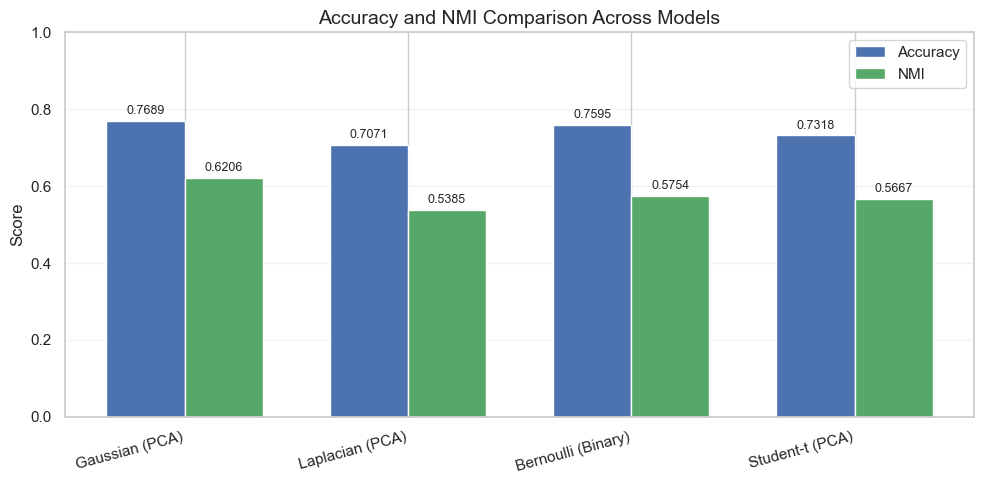

In [11]:
import os

# Grouped bar chart for the two headline metrics
comparison = df_metrics[['Accuracy', 'NMI']].copy()
model_labels = comparison.index.tolist()

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_acc = ax.bar(x - width/2, comparison['Accuracy'].values, width, label='Accuracy', color='#4C72B0')
bars_nmi = ax.bar(x + width/2, comparison['NMI'].values, width, label='NMI', color='#55A868')

ax.set_title('Accuracy and NMI Comparison Across Models', fontsize=14)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.25)

for bars in [bars_acc, bars_nmi]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.4f}', ha='center', va='bottom', fontsize=9)

os.makedirs('images', exist_ok=True)
plt.tight_layout()
plt.savefig('images/final_comparison_chart.png', dpi=200, bbox_inches='tight')
plt.savefig('data/final_comparison_chart.png', dpi=200, bbox_inches='tight')
plt.show()

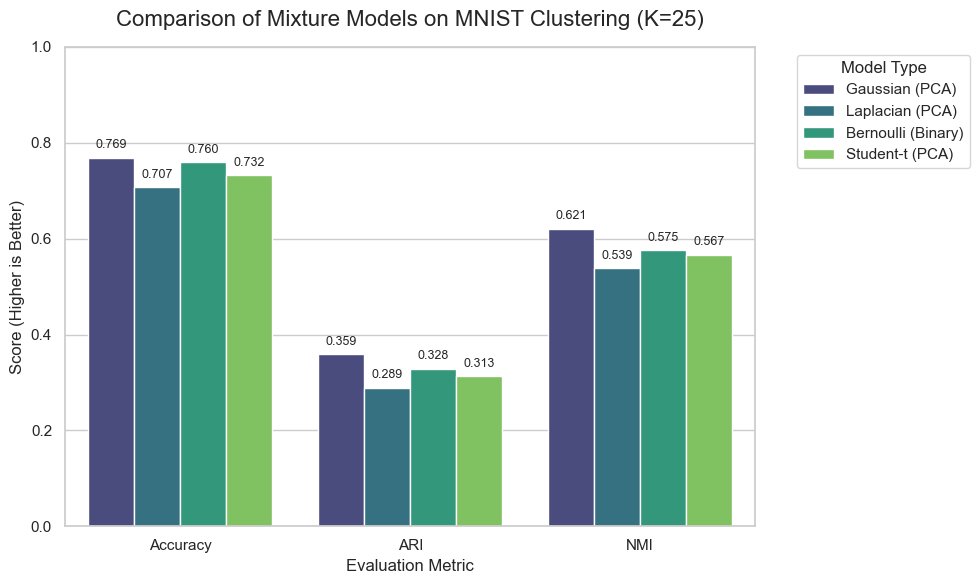

In [2]:
# Set up the bar chart
sns.set_theme(style="whitegrid")
df_melted = df_metrics.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Metric', y='Score', hue='index', data=df_melted, palette='viridis')

plt.title('Comparison of Mixture Models on MNIST Clustering (K=25)', fontsize=16, pad=15)
plt.ylabel('Score (Higher is Better)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0, 1.0) # Metrics are naturally bounded between 0 and 1
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add text labels on top of the bars
for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(format(p.get_height(), '.3f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points',
                         fontsize=9)

plt.tight_layout()
plt.show()

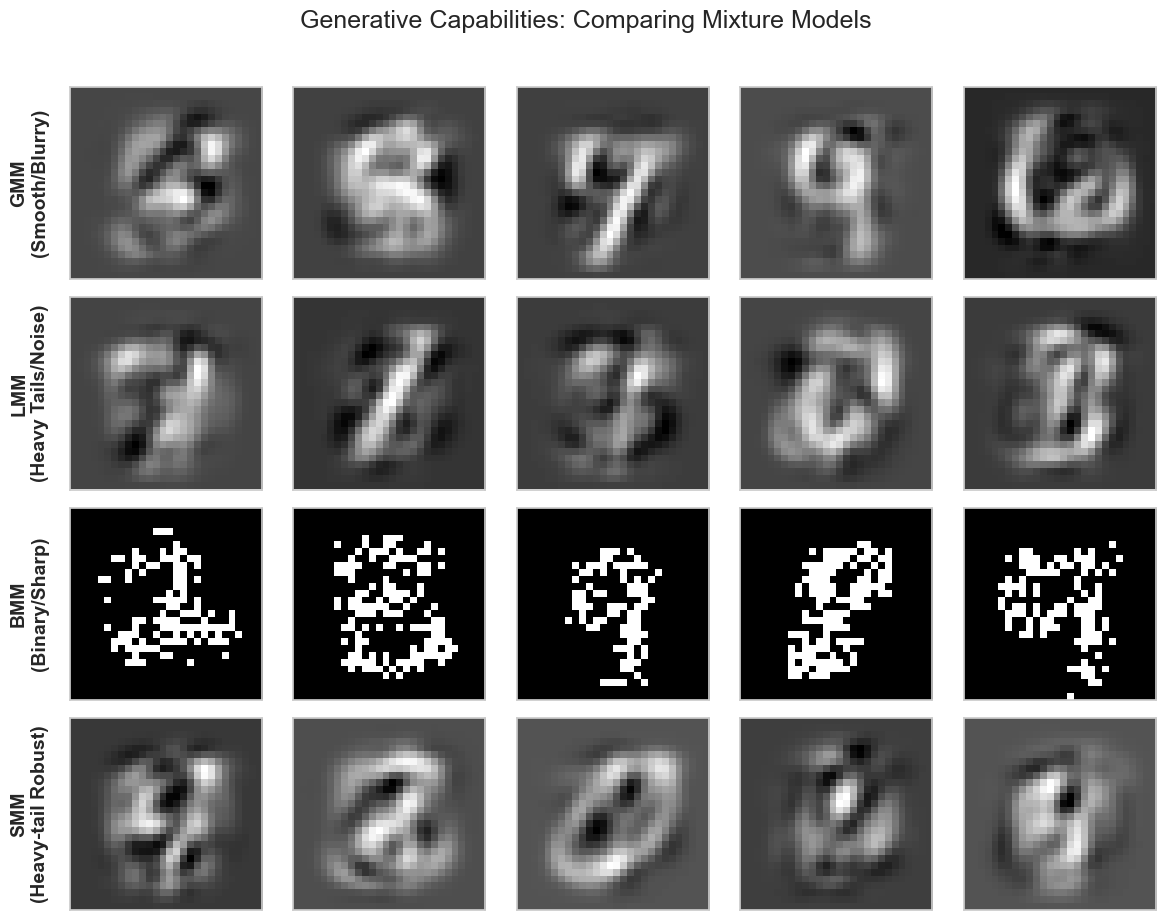

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the saved 784-dimensional samples
gmm_samples = np.load('data/gmm_samples.npy')
lmm_samples = np.load('data/lmm_samples.npy')
bmm_samples = np.load('data/bmm_samples.npy')
smm_samples = np.load('data/smm_samples.npy')

# 2. Create the 4x5 grid
fig, axes = plt.subplots(4, 5, figsize=(12, 9))
fig.suptitle("Generative Capabilities: Comparing Mixture Models", fontsize=18, y=1.02)

# 3. Helper function to plot a single row
def plot_model_row(ax_row, samples, model_name):
    # Set the label for the row on the far left image
    ax_row[0].set_ylabel(model_name, fontsize=14, fontweight='bold', labelpad=15)

    for i in range(5):
        # Reshape the flat 784-dimensional array back to 28x28
        img = samples[i].reshape(28, 28)

        # Plot the image
        ax_row[i].imshow(img, cmap='gray')

        # Remove tick marks to keep it clean, but keep the y-axis label on the first column
        ax_row[i].set_xticks([])
        ax_row[i].set_yticks([])

# 4. Plot each model's samples
plot_model_row(axes[0], gmm_samples, "GMM\n(Smooth/Blurry)")
plot_model_row(axes[1], lmm_samples, "LMM\n(Heavy Tails/Noise)")
plot_model_row(axes[2], bmm_samples, "BMM\n(Binary/Sharp)")
plot_model_row(axes[3], smm_samples, "SMM\n(Heavy-tail Robust)")

os.makedirs('images', exist_ok=True)
plt.tight_layout()
plt.savefig('images/model_samples_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

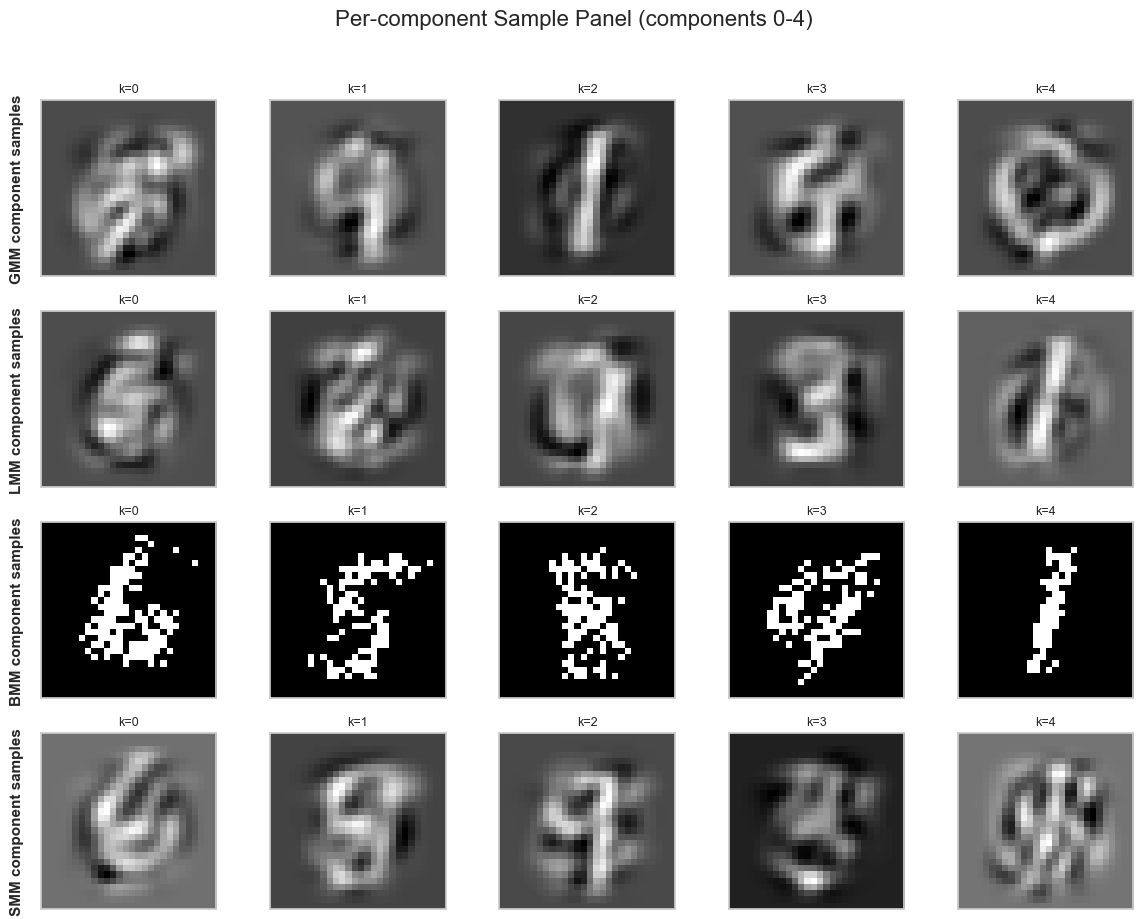

In [12]:
# Compact per-component generation panel (subset of components)
import os
import pickle

with open('data/pca_model.pkl', 'rb') as f:
    pca_model = pickle.load(f)

subset_components = [0, 1, 2, 3, 4]

def draw_component_samples(model_name):
    samples = []
    for k in subset_components:
        if model_name == 'GMM':
            mean = gmm_hold.means_[k]
            var = np.clip(gmm_hold.covariances_[k], 1e-6, None)
            pca_sample = np.random.normal(loc=mean, scale=np.sqrt(var), size=(1, mean.shape[0]))
            img = pca_model.inverse_transform(pca_sample)[0]
        elif model_name == 'LMM':
            pca_sample = lmm_hold.sample_from_component(k, n=1)
            img = pca_model.inverse_transform(pca_sample)[0]
        elif model_name == 'BMM':
            bin_sample = bmm_hold.sample_from_component(k, n=1)
            img = bin_sample[0]
        else:  # SMM
            pca_sample = smm_hold.sample_from_component(k, n=1)
            img = pca_model.inverse_transform(pca_sample)[0]
        samples.append(img.reshape(28, 28))
    return samples

panel = {
    'GMM component samples': draw_component_samples('GMM'),
    'LMM component samples': draw_component_samples('LMM'),
    'BMM component samples': draw_component_samples('BMM'),
    'SMM component samples': draw_component_samples('SMM'),
}

fig, axes = plt.subplots(4, 5, figsize=(12, 9))
fig.suptitle('Per-component Sample Panel (components 0-4)', fontsize=16, y=1.02)

for r, (row_name, imgs) in enumerate(panel.items()):
    axes[r, 0].set_ylabel(row_name, fontsize=11, fontweight='bold', labelpad=12)
    for c in range(5):
        axes[r, c].imshow(imgs[c], cmap='gray')
        axes[r, c].set_title(f'k={subset_components[c]}', fontsize=9)
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])

os.makedirs('images', exist_ok=True)
plt.tight_layout()
plt.savefig('images/per_component_samples_panel.png', dpi=200, bbox_inches='tight')
plt.show()